In [1]:
print(' Hello world')

 Hello world


## Importing Libraries

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')
df

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [4]:
# check dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [5]:
df.shape

(7500, 16)

In [6]:
df.columns

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')

## 2 Problem Statement

#### Smartphone Usage & Addiction Analysis

### Problem Statement
- We want to predict whether a user is addicted to smartphone usage using behavioural and usage features.

In [7]:
# target column

df["addicted_label"].value_counts()

# Type of Machine Learning Problem  : Because target has categories (0 or 1): Classification Problem

## More specifically: Binary Classification

addicted_label
1    5308
0    2192
Name: count, dtype: int64

In [8]:
X = df.drop("addicted_label", axis=1)

y = df["addicted_label"]

In [9]:
X

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe


In [10]:
y

0       0
1       0
2       0
3       1
4       1
       ..
7495    1
7496    0
7497    1
7498    1
7499    1
Name: addicted_label, Length: 7500, dtype: int64

## 3  Basic Cleaning

In [11]:
df

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [12]:
df_clean = df.copy()
df_clean

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [13]:
df_clean.columns

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')

In [14]:
# droping id columns
df_clean = df_clean.drop(columns=["transaction_id","user_id"])
df_clean

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [15]:
df_clean.duplicated().sum()

np.int64(0)

In [16]:
df_clean.isnull().sum()

age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

In [17]:
df_clean.dtypes

age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object

In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      7500 non-null   int64  
 1   gender                   7500 non-null   object 
 2   daily_screen_time_hours  7500 non-null   float64
 3   social_media_hours       7500 non-null   float64
 4   gaming_hours             7500 non-null   float64
 5   work_study_hours         7500 non-null   float64
 6   sleep_hours              7500 non-null   float64
 7   notifications_per_day    7500 non-null   int64  
 8   app_opens_per_day        7500 non-null   int64  
 9   weekend_screen_time      7500 non-null   float64
 10  stress_level             7500 non-null   object 
 11  academic_work_impact     7500 non-null   object 
 12  addiction_level          6681 non-null   object 
 13  addicted_label           7500 non-null   int64  
dtypes: float64(6), int64(4),

## 4 Feature Engineering

In [19]:
df_clean

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [20]:
X = df_clean.drop(["addicted_label", "addiction_level"], axis=1)
y = df_clean["addicted_label"]

In [21]:
X

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact
0,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes
1,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes
2,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No
3,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes
4,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...
7495,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes
7496,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No
7497,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes
7498,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes


In [22]:
y

0       0
1       0
2       0
3       1
4       1
       ..
7495    1
7496    0
7497    1
7498    1
7499    1
Name: addicted_label, Length: 7500, dtype: int64

In [23]:
X.columns

Index(['age', 'gender', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact'],
      dtype='object')

In [24]:
#  entertainment ratio
X["entertainment_ratio"] = ((X["social_media_hours"] + X["gaming_hours"])/ X["daily_screen_time_hours"])
X['entertainment_ratio']

0       0.897833
1       1.188605
2       0.856436
3       0.939974
4       0.937751
          ...   
7495    0.495431
7496    0.897707
7497    0.470470
7498    0.189931
7499    0.610558
Name: entertainment_ratio, Length: 7500, dtype: float64

In [25]:

#  weekend behaviour

X["weekend_usage_diff"] = (X["weekend_screen_time"]- X["daily_screen_time_hours"])
X['weekend_usage_diff']

0       0.72
1       1.62
2       2.62
3       1.94
4       2.59
        ... 
7495    2.14
7496    1.41
7497    2.85
7498    1.78
7499    2.13
Name: weekend_usage_diff, Length: 7500, dtype: float64

In [26]:
#  notification engagement
X["opens_per_notification"] = (X["app_opens_per_day"]/ X["notifications_per_day"])

X["opens_per_notification"].isnull().sum()

np.int64(0)

In [27]:

#  sleep deficit

X["sleep_deficit"] = 7 - X["sleep_hours"]
X['sleep_deficit']

0      -0.55
1      -0.66
2       2.08
3      -1.23
4       0.79
        ... 
7495    1.19
7496   -1.47
7497   -1.17
7498    0.81
7499    1.42
Name: sleep_deficit, Length: 7500, dtype: float64

In [28]:
# identify column types
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

print(cat_cols)
print(num_cols)

Index(['gender', 'stress_level', 'academic_work_impact'], dtype='object')
Index(['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time', 'entertainment_ratio',
       'weekend_usage_diff', 'opens_per_notification', 'sleep_deficit'],
      dtype='object')


In [29]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      7500 non-null   int64  
 1   gender                   7500 non-null   object 
 2   daily_screen_time_hours  7500 non-null   float64
 3   social_media_hours       7500 non-null   float64
 4   gaming_hours             7500 non-null   float64
 5   work_study_hours         7500 non-null   float64
 6   sleep_hours              7500 non-null   float64
 7   notifications_per_day    7500 non-null   int64  
 8   app_opens_per_day        7500 non-null   int64  
 9   weekend_screen_time      7500 non-null   float64
 10  stress_level             7500 non-null   object 
 11  academic_work_impact     7500 non-null   object 
 12  entertainment_ratio      7500 non-null   float64
 13  weekend_usage_diff       7500 non-null   float64
 14  opens_per_notification  

## 5 Train Test Split

In [30]:
from sklearn.model_selection import train_test_split

In [31]:

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [32]:
print(X_train.shape)
print(X_test.shape)

(6000, 16)
(1500, 16)


In [33]:

print(y_train.value_counts())
print(y_test.value_counts())

addicted_label
1    4246
0    1754
Name: count, dtype: int64
addicted_label
1    1062
0     438
Name: count, dtype: int64


In [34]:

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

addicted_label
1    0.707667
0    0.292333
Name: proportion, dtype: float64
addicted_label
1    0.708
0    0.292
Name: proportion, dtype: float64


## 6 Preprocessing

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder ,StandardScaler
from sklearn.impute import SimpleImputer

In [36]:
nominal_cols = ["gender"]

ordinal_cols = ["stress_level","academic_work_impact"]

In [37]:
for col in ordinal_cols:
    print(col, X_train[col].unique())

stress_level ['Medium' 'High' 'Low']
academic_work_impact ['Yes' 'No']


In [38]:
# order for ordinal columns

stress_order = ["Low", "Medium", "High"]
impact_order = ["No", "Yes"]

In [39]:
num_cols

Index(['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time', 'entertainment_ratio',
       'weekend_usage_diff', 'opens_per_notification', 'sleep_deficit'],
      dtype='object')

In [40]:
X_train[num_cols].isnull().sum()

age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
entertainment_ratio        0
weekend_usage_diff         0
opens_per_notification     0
sleep_deficit              0
dtype: int64

In [41]:
X_train[cat_cols].isnull().sum()

gender                  0
stress_level            0
academic_work_impact    0
dtype: int64

In [42]:

# column transformer

preprocessor = ColumnTransformer(transformers=[

    # numerical scaling
    ("num",StandardScaler(),num_cols),

    # nominal encoding
    ("nominal",OneHotEncoder(handle_unknown="ignore", sparse_output=False),nominal_cols),

    # ordinal encoding
    ("ordinal",OrdinalEncoder(categories=[stress_order,impact_order]),ordinal_cols)
    
    ], remainder="drop")

In [43]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

In [44]:
# Fit transformer on training data
X_train_processed = preprocessor.fit_transform(X_train)

In [45]:
# transform on test data
X_test_processed = preprocessor.transform(X_test)

In [46]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

In [47]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(6000, 18)
(1500, 18)


In [48]:
X_train_processed

array([[ 0.84564732, -0.89075745,  0.5660007 , ...,  0.        ,
         1.        ,  1.        ],
       [ 1.03786901,  0.83024327,  1.33318786, ...,  1.        ,
         2.        ,  1.        ],
       [-0.30768286,  0.82640175, -0.95579676, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.69212626, -0.59880197, -0.15087909, ...,  0.        ,
         0.        ,  1.        ],
       [-1.07656965, -1.10588254,  0.15096503, ...,  0.        ,
         2.        ,  1.        ],
       [ 0.07676053, -0.25306522, -0.99352727, ...,  0.        ,
         2.        ,  0.        ]], shape=(6000, 18))

In [49]:
X_test_processed

array([[ 1.03786901, -0.75630427, -1.30165982, ...,  0.        ,
         2.        ,  1.        ],
       [ 0.84564732,  0.65353338, -0.13201383, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.84564732, -1.40936258, -1.59721552, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.65323474,  1.07610052,  1.3143226 , ...,  0.        ,
         0.        ,  1.        ],
       [ 1.6145341 ,  0.3807855 ,  1.65389724, ...,  1.        ,
         2.        ,  0.        ],
       [-0.88434795,  0.67274098,  0.53455861, ...,  1.        ,
         0.        ,  1.        ]], shape=(1500, 18))

In [50]:
encoded_feature_names = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(X_train_processed,columns=encoded_feature_names,index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed,columns=encoded_feature_names,index=X_test.index)

In [51]:
X_train_processed.head()

,num__age,num__daily_screen_time_hours,num__social_media_hours,num__gaming_hours,num__work_study_hours,num__sleep_hours,num__notifications_per_day,num__app_opens_per_day,num__weekend_screen_time,num__entertainment_ratio,num__weekend_usage_diff,num__opens_per_notification,num__sleep_deficit,nominal__gender_Female,nominal__gender_Male,nominal__gender_Other,ordinal__stress_level,ordinal__academic_work_impact
5171,0.845647,-0.890757,0.566001,0.317139,0.538647,1.238562,1.161997,-1.167484,-1.213161,0.953042,-1.351359,-0.779373,-1.238562,1.0,0.0,0.0,1.0,1.0
6534,1.037869,0.830243,1.333188,-0.371107,0.213916,-0.631536,0.232537,1.491283,0.437582,-0.195655,-1.351359,0.040756,0.631536,0.0,0.0,1.0,2.0,1.0
1737,-0.307683,0.826402,-0.955797,-0.144596,-1.172436,0.911295,-1.026731,1.140903,1.126620,-0.936194,1.257898,1.074580,-0.911295,0.0,1.0,0.0,0.0,1.0
3749,0.845647,-0.210809,0.427655,-0.423379,-0.747788,0.030790,0.682276,-0.487334,-0.627295,-0.056162,-1.601182,-0.589409,-0.030790,0.0,0.0,1.0,2.0,1.0
63,-1.268791,-0.933014,0.597443,1.240609,0.301343,-1.675675,1.206971,-0.301839,-0.822583,1.475560,0.272487,-0.611279,1.675675,1.0,0.0,0.0,0.0,0.0


In [52]:
X_test_processed.head()

,num__age,num__daily_screen_time_hours,num__social_media_hours,num__gaming_hours,num__work_study_hours,num__sleep_hours,num__notifications_per_day,num__app_opens_per_day,num__weekend_screen_time,num__entertainment_ratio,num__weekend_usage_diff,num__opens_per_notification,num__sleep_deficit,nominal__gender_Female,nominal__gender_Male,nominal__gender_Other,ordinal__stress_level,ordinal__academic_work_impact
7103,1.037869,-0.756304,-1.301660,-0.057476,0.957050,1.729463,-1.656365,0.295869,-0.597817,-0.520423,0.480672,3.123719,-1.729463,0.0,1.0,0.0,2.0,1.0
5175,0.845647,0.653533,-0.132014,0.744026,1.306760,-0.249724,1.506797,-1.332369,0.990286,-0.360964,1.368930,-0.825592,0.249724,1.0,0.0,0.0,0.0,0.0
5911,0.845647,-1.409363,-1.597216,1.284169,1.419167,-1.340615,-0.307149,0.563806,-0.981025,0.608258,1.396688,0.008610,1.340615,0.0,1.0,0.0,1.0,0.0
801,-0.884348,1.675378,0.459098,0.953114,-1.072519,0.545068,-0.876818,-0.136954,1.325593,-0.456258,-1.059900,0.096629,-0.545068,0.0,0.0,1.0,0.0,0.0
1962,0.076761,1.248969,-1.087854,-1.503665,0.188936,1.635958,-1.581409,1.656168,1.200313,-1.365749,0.008785,4.407452,-1.635958,0.0,1.0,0.0,2.0,1.0


In [53]:
X_train_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6000 entries, 5171 to 6555
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   num__age                       6000 non-null   float64
 1   num__daily_screen_time_hours   6000 non-null   float64
 2   num__social_media_hours        6000 non-null   float64
 3   num__gaming_hours              6000 non-null   float64
 4   num__work_study_hours          6000 non-null   float64
 5   num__sleep_hours               6000 non-null   float64
 6   num__notifications_per_day     6000 non-null   float64
 7   num__app_opens_per_day         6000 non-null   float64
 8   num__weekend_screen_time       6000 non-null   float64
 9   num__entertainment_ratio       6000 non-null   float64
 10  num__weekend_usage_diff        6000 non-null   float64
 11  num__opens_per_notification    6000 non-null   float64
 12  num__sleep_deficit             6000 non-null   flo

In [54]:
X_test_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 7103 to 7129
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   num__age                       1500 non-null   float64
 1   num__daily_screen_time_hours   1500 non-null   float64
 2   num__social_media_hours        1500 non-null   float64
 3   num__gaming_hours              1500 non-null   float64
 4   num__work_study_hours          1500 non-null   float64
 5   num__sleep_hours               1500 non-null   float64
 6   num__notifications_per_day     1500 non-null   float64
 7   num__app_opens_per_day         1500 non-null   float64
 8   num__weekend_screen_time       1500 non-null   float64
 9   num__entertainment_ratio       1500 non-null   float64
 10  num__weekend_usage_diff        1500 non-null   float64
 11  num__opens_per_notification    1500 non-null   float64
 12  num__sleep_deficit             1500 non-null   flo

## 7 Train Multiple Models

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay

### 1 .Logistic Regression

In [57]:
from sklearn.linear_model import LogisticRegression

# creating model
lr_model = LogisticRegression(max_iter=1000)
lr_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [58]:
# train model
lr_model.fit(X_train_processed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [59]:
# predict
y_pred_lr = lr_model.predict(X_test_processed)
y_pred_lr

array([0, 1, 0, ..., 1, 1, 1], shape=(1500,))

In [60]:
# score

lr_model.score(X_test_processed, y_test)

0.916

In [61]:
# evaluation of logistic regrission 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [62]:

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.916
Precision: 0.9317343173431735
Recall: 0.9510357815442562
F1 score: 0.9412861136999068


In [63]:
y_test.value_counts()

addicted_label
1    1062
0     438
Name: count, dtype: int64

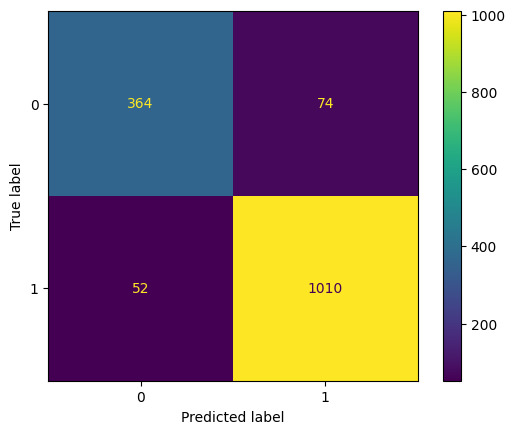

In [64]:
cm = confusion_matrix(y_test, y_pred_lr)
cm

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### 2.Decision Tree Classifier

In [65]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [66]:
# Train model
dt_model.fit(X_train_processed, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [67]:
# predict 
y_pred_dt = dt_model.predict(X_test_processed)
y_pred_dt

array([0, 1, 0, ..., 1, 1, 1], shape=(1500,))

In [68]:
# score
dt_model.score(X_test_processed, y_test)

0.938

In [69]:
## Evaluate 
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)



print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.938
Precision: 0.9566446748350612
Recall: 0.955743879472693
F1 score: 0.9561940650023552


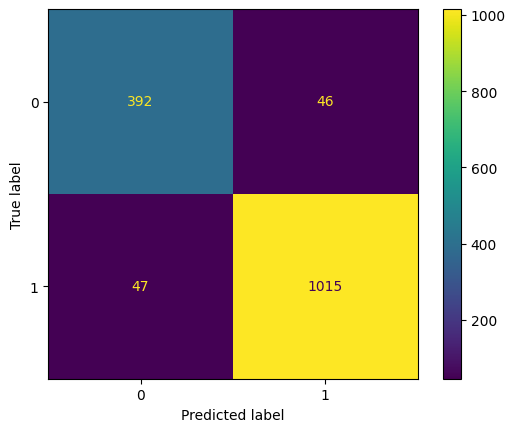

In [70]:
cm = confusion_matrix(y_test, y_pred_dt)
cm

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### 3 RandomForestClassifier

In [71]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [72]:

# train
rf_model.fit(X_train_processed, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [73]:
# predict 
y_pred_rf = rf_model.predict(X_test_processed)
y_pred_rf

array([0, 1, 0, ..., 1, 1, 1], shape=(1500,))

In [74]:
# score 
rf_model.score(X_test_processed , y_test)

0.9393333333333334

In [75]:
# evaluate

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.9393333333333334
Precision: 0.9681774349083896
Recall: 0.9453860640301318
F1 score: 0.9566460219151978


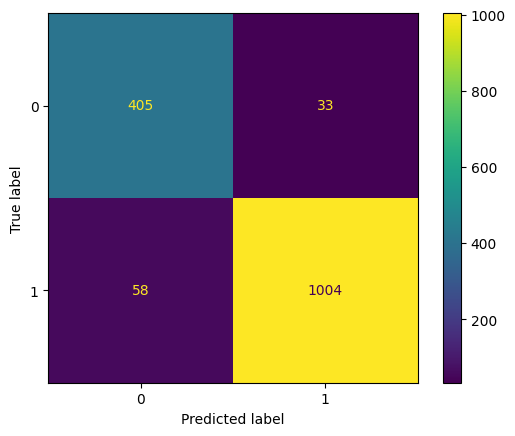

In [76]:
cm = confusion_matrix(y_test, y_pred_rf)
cm

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### 4 .KNN

In [77]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [78]:
# train
knn_model.fit(X_train_processed, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [79]:
# predict

y_pred_knn = knn_model.predict(X_test_processed)

c:\Users\sidda\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:150: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\sidda\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 227, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\sidda\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\sidda\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  

In [80]:
# score 
knn_model.score(X_test_processed , y_test)

0.8886666666666667

In [81]:
accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.8886666666666667
Precision: 0.9109274563820018
Recall: 0.9340866290018832
F1 score: 0.9223616922361693


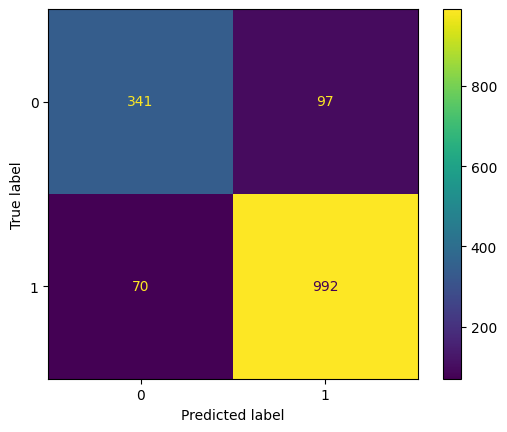

In [82]:
cm = confusion_matrix(y_test, y_pred_knn)
cm

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### 5 .SVM

In [83]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [84]:
# train

svm_model.fit(X_train_processed, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [85]:
# predict 
y_pred_svm = svm_model.predict(X_test_processed)
y_pred_svm

array([0, 1, 0, ..., 1, 1, 1], shape=(1500,))

In [86]:
# score
svm_model.score(X_test_processed,y_test)

0.9113333333333333

In [87]:
accuracy = accuracy_score(y_test, y_pred_svm)
precision = precision_score(y_test, y_pred_svm)
recall = recall_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.9113333333333333
Precision: 0.9312906220984215
Recall: 0.9444444444444444
F1 score: 0.9378214118747078


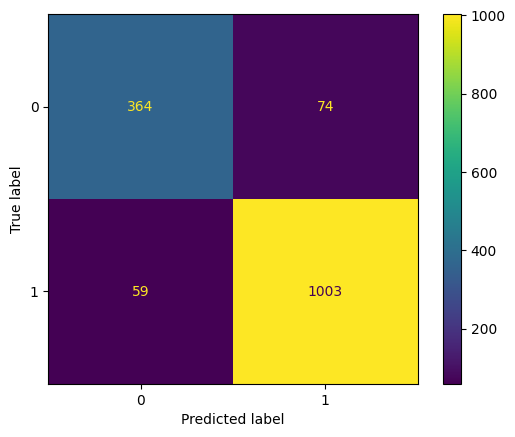

In [88]:
# confussion matrix

cm = confusion_matrix(y_test, y_pred_svm)
cm

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### Model Comparison

In [89]:
results = {

    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr),
        "Recall": recall_score(y_test, y_pred_lr),
        "F1": f1_score(y_test, y_pred_lr)
    },

    "Decision Tree": {
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt),
        "Recall": recall_score(y_test, y_pred_dt),
        "F1": f1_score(y_test, y_pred_dt)
    },

    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1": f1_score(y_test, y_pred_rf)
    },

    "KNN": {
        "Accuracy": accuracy_score(y_test, y_pred_knn),
        "Precision": precision_score(y_test, y_pred_knn),
        "Recall": recall_score(y_test, y_pred_knn),
        "F1": f1_score(y_test, y_pred_knn)
    },

    "SVM": {
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "Precision": precision_score(y_test, y_pred_svm),
        "Recall": recall_score(y_test, y_pred_svm),
        "F1": f1_score(y_test, y_pred_svm)
    }

}

In [90]:
results_df = pd.DataFrame(results)
results_df.T

,Accuracy,Precision,Recall,F1
Logistic Regression,0.916000,0.931734,0.951036,0.941286
Decision Tree,0.938000,0.956645,0.955744,0.956194
Random Forest,0.939333,0.968177,0.945386,0.956646
KNN,0.888667,0.910927,0.934087,0.922362
SVM,0.911333,0.931291,0.944444,0.937821


#### Best Model : Random Forest

- Why best?

    - highest F1 score
    - highest precision
    - strong recall
    - robust to noise
    - handles feature interactions well

## 8 Hyper parameter tuning
#### goal 
- Find best parameter combination that improves performance.
- Instead of using default values, we search for optimal settings.

#### Why tune Random Forest?

- Random Forest performance depends on parameters like:

    - n_estimators :	number of trees
    - max_depth	: maximum depth of each tree
    - min_samples_split:	minimum samples needed to split node
    - min_samples_leaf:	minimum samples in leaf
    - max_features	:number of features considered per split

- Tuning helps model generalize better.

In [91]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [92]:
# Define parameter grid : We try multiple values

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
    }

In [93]:
# base model

rf = RandomForestClassifier(random_state=42)
rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [94]:
# GridSearchCV

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [95]:
# Train with hyperparameter search

grid_search.fit(X_train_processed, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [96]:
# Best parameters

grid_search.best_params_

{'max_depth': 15,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}

In [97]:
# best model

best_rf = grid_search.best_estimator_

In [98]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_best = best_rf.predict(X_test_processed)

print("Accuracy:", accuracy_score(y_test, y_pred_best))

print("Precision:", precision_score(y_test, y_pred_best))

print("Recall:", recall_score(y_test, y_pred_best))

print("F1 score:", f1_score(y_test, y_pred_best))

Accuracy: 0.9373333333333334
Precision: 0.9644913627639156
Recall: 0.9463276836158192
F1 score: 0.9553231939163498


## 9  Final Evaluation

In [99]:
# Make predictions using best model

y_pred_final = best_rf.predict(X_test_processed)
y_pred_final

array([0, 1, 0, ..., 1, 1, 1], shape=(1500,))

In [100]:
# Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       438
           1       0.96      0.95      0.96      1062

    accuracy                           0.94      1500
   macro avg       0.92      0.93      0.93      1500
weighted avg       0.94      0.94      0.94      1500



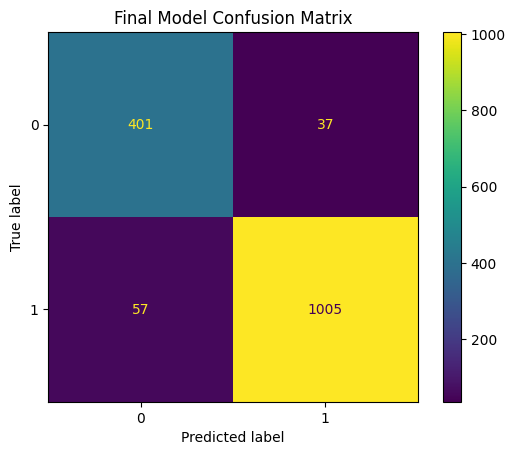

In [101]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Final Model Confusion Matrix")
plt.show()

In [102]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1 Score:", f1_score(y_test, y_pred_final))

Accuracy: 0.9373333333333334
Precision: 0.9644913627639156
Recall: 0.9463276836158192
F1 Score: 0.9553231939163498


## Save Model (.pkl)

In [103]:
import pickle

# save model
with open("smartphone_addiction_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)

# save preprocessor
with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

print("Model saved successfully")

Model saved successfully
